# Indoor scene completion from a single sensor viewpoint

Verification notebook for the retrained Replica (indoor) models. It:

1. loads one ground-truth patch,
2. places a sensor in the room and ray-casts to work out what it can actually see,
3. throws away everything occluded,
4. completes the scene with the structure + semantic diffusion models,
5. compares the completion against the ground truth it never saw.

This is the indoor counterpart to `notebooks/kitti/03_completion_then_outpaint.ipynb`.
The outdoor notebooks carve their observed/unobserved mask by reverse ray-tracing
from the LiDAR origin; there was no indoor equivalent, so `utils/sensor_sim.py`
provides one.

Everything renders inline with matplotlib — no Open3D windows, so this works over SSH.

In [1]:
import os, sys, glob

# run from the repo root regardless of where the notebook was launched
# (anchor on pyproject.toml -- main.py was removed when the CLI landed)
root = os.getcwd()
while not os.path.exists(os.path.join(root, "pyproject.toml")) and root != "/":
    root = os.path.dirname(root)
os.chdir(root)
sys.path.insert(0, root)
print("repo root:", root)

import torch, numpy as np, matplotlib.pyplot as plt

from octree_diff.inference.pipeline import (
    IndoorPipeline, labels_to_split_big, split_big_to_octree, build_doctree,
    voxel_mask_to_latent_mask, voxel_mask_to_node_mask,
)
from octree_diff.inference.sensor_sim import simulate_sensor, pick_viewpoint, observed_labels
from octree_diff.viz.vis_indoor import (
    plot_3d, plot_slice, plot_state, compare_row, legend_for,
    class_colors, completion_metrics, CEILING,
)

DEVICE = "cuda"
torch.manual_seed(0)
COLORS = class_colors(200)

# NB: utils/util_dualoctree.py calls matplotlib.use("Agg") at import time, which
# kills inline figures — so re-enable the inline backend *after* the imports.
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

repo root: <repo>


## 1. Load a frame

Patches are `[64,128,128]` on disk (D,H,W) and get permuted to `[128,128,64]` (H,W,D),
which is the orientation everything downstream expects. At 5 cm voxels that is a
6.4 x 6.4 x 3.2 m chunk of a room.

Label ids here are a **remapped** space, not raw Replica class ids — the mapping was
not preserved by the preprocessing. The three dominant classes were identified
geometrically instead (id 1 sits at the bottom of every patch, id 3 at the top, id 2
is thin and vertical), so floor / wall / ceiling are named and everything else is
shown by id.

In [2]:
PATCH = sorted(glob.glob("data/patches_val/*.pt"))[3]

blob = torch.load(PATCH, map_location="cpu")
gt = blob["labels"].long().permute(1, 2, 0).contiguous().to(DEVICE)

print(f"{PATCH}   scene = {blob['meta']['scene']}")
print(f"shape {tuple(gt.shape)}   occupied {int((gt>0).sum()):,} voxels "
      f"({(gt>0).float().mean():.1%})   {len(gt.unique())} classes present")

/tmp/ipykernel_1507741/272423395.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  blob = torch.load(PATCH, map_location="cpu")


data/patches_val/0003.pt   scene = apartment_0
shape (128, 128, 64)   occupied 70,738 voxels (6.7%)   29 classes present


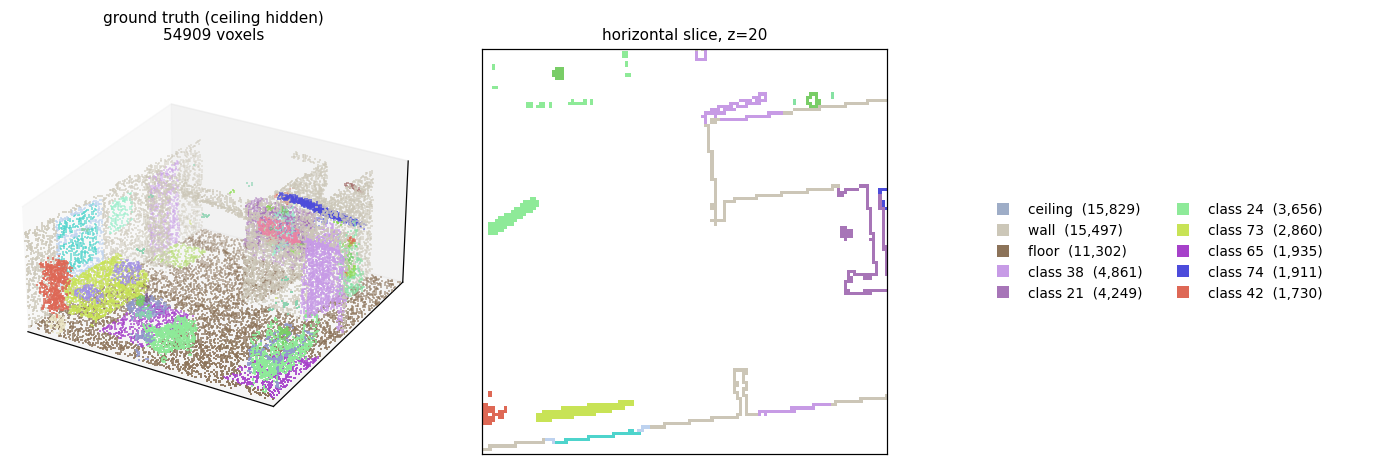

In [3]:
fig = plt.figure(figsize=(13, 4.2))
ax1 = fig.add_subplot(131, projection="3d")
plot_3d(gt, ax=ax1, title="ground truth (ceiling hidden)", colors=COLORS)
ax2 = fig.add_subplot(132)
plot_slice(gt, z=20, ax=ax2, title="horizontal slice, z=20", colors=COLORS)
ax3 = fig.add_subplot(133)
legend_for([gt], ax3, top=10, colors=COLORS)
fig.tight_layout()

## 2. Put a sensor in the room

`pick_viewpoint` finds a free voxel near the middle of the scene at roughly eye
height, preferring open space so the sensor is not wedged inside furniture.

`simulate_sensor` then marches rays over an azimuth x elevation grid and labels every
voxel:

| state | meaning |
|---|---|
| `0`  | **free** — a ray passed through it |
| `1`  | **observed** — a ray terminated on it, so it is a seen surface |
| `-1` | **unknown** — occluded, out of range, or outside the field of view |

Only `-1` is the completion problem. Free space counts as known: the sensor genuinely
knows nothing is there.

In [4]:
occ = gt > 0
viewpoint = pick_viewpoint(occ, height_frac=0.4)
state = simulate_sensor(occ, viewpoint, n_az=720, n_el=160,
                        fov_v=(-35, 35), device=DEVICE)

partial, known = observed_labels(gt, state)

seen = int((occ & known).sum())
hidden = int((occ & ~known).sum())
print(f"viewpoint {viewpoint}")
print(f"volume observed        {known.float().mean():.1%}")
print(f"surfaces seen          {seen:,} / {seen+hidden:,}  ({seen/(seen+hidden):.0%})")
print(f"surfaces to reconstruct {hidden:,}")

viewpoint (63, 63, 25)
volume observed        49.5%
surfaces seen          24,907 / 70,738  (35%)
surfaces to reconstruct 45,831


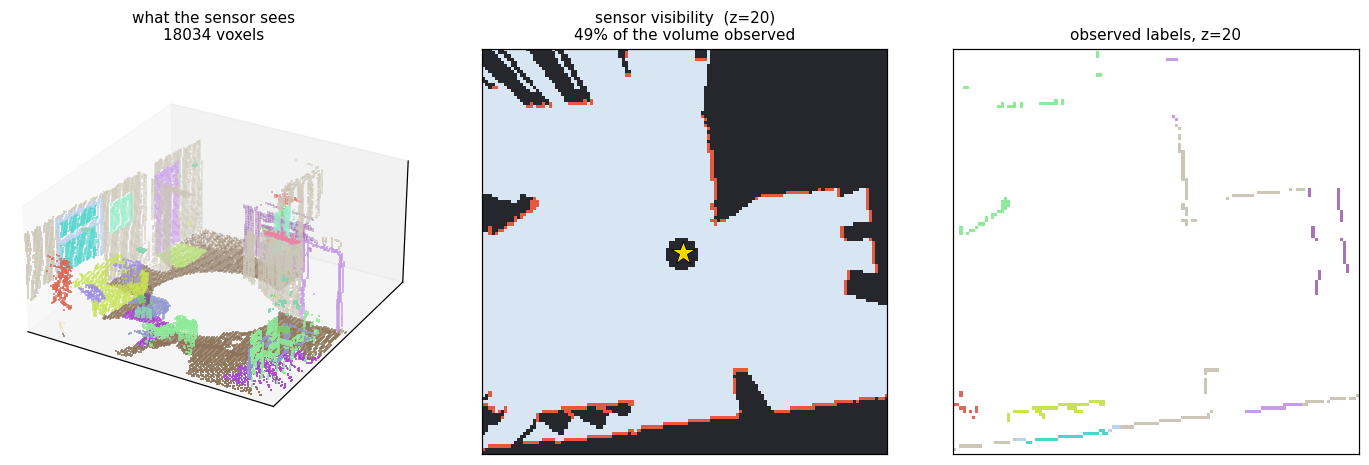

In [5]:
fig = plt.figure(figsize=(13, 4.2))
ax1 = fig.add_subplot(131, projection="3d")
plot_3d(partial, ax=ax1, title="what the sensor sees", colors=COLORS)
ax2 = fig.add_subplot(132)
plot_state(state, ax=ax2, z=20)
ax2.plot(viewpoint[1], viewpoint[0], "*", color="gold", markersize=16,
         markeredgecolor="k", markeredgewidth=0.6)
ax3 = fig.add_subplot(133)
plot_slice(partial, z=20, ax=ax3, title="observed labels, z=20", colors=COLORS)
fig.tight_layout()

The dark region in the middle panel is everything the model has to invent: shadows
behind furniture, the far side of every object, and anything outside the vertical
field of view. The gold star is the sensor.

## 3. Load the models

Four checkpoints: structure VAE + diffusion (scene layout, on a `[2,32,32,32]` latent)
and semantic VAE + diffusion (per-class labels, on an octree graph latent).

The diffusion models were trained on latents rescaled to ~unit variance, so the scale
factors are read back from the sidecars and divided out before decoding.

In [6]:
pipe = IndoorPipeline(DEVICE)
print(f"latent scales: structure {pipe.str_scale:.4f}, semantic {pipe.sem_scale:.4f}")

latent scales: structure 2.0029, semantic 3.0764


## 4. Complete the structure

The layout is completed first. The observed labels are reduced to an occupancy octree
and then to the `[1,1,32,32,32]` split grid the structure VAE works on; the visibility
mask is reduced the same way (4x4x2 voxel blocks per split cell) and used as the known
region for RePaint-style inpainting in the VAE latent.

`repaint_resample > 1` re-noises and re-denoises at each step, which gives the
generated region more chances to agree with what is known. It costs that many model
evaluations per step.

In [7]:
STEPS = 100
RESAMPLE = 4
BEST_OF = 3      # see section 9 — rejects the occasional bad layout draw

split_known = labels_to_split_big(partial, DEVICE)
latent_mask = voxel_mask_to_latent_mask(known)

split_out, agree = pipe.inpaint_structure(split_known, latent_mask, steps=STEPS,
                                          resample=RESAMPLE, best_of=BEST_OF,
                                          return_score=True)
print(f"agreement with the observed region: {agree:.3f}")

split_gt = labels_to_split_big(gt, DEVICE)
a, b = split_out > 0, split_gt > 0
print(f"split-grid occupancy: input {(split_known>0).float().mean():.3f}  "
      f"completed {a.float().mean():.3f}  ground truth {b.float().mean():.3f}")
print(f"IoU vs ground-truth layout: {((a&b).sum()/(a|b).sum()).item():.3f}")

  loaded structure_vae from <repo>/saved_model/structure_vae.pt


  loaded structure_diffusion from <repo>/saved_model/structure_diffusion.pt


agreement with the observed region: 0.980
split-grid occupancy: input 0.101  completed 0.179  ground truth 0.191
IoU vs ground-truth layout: 0.902


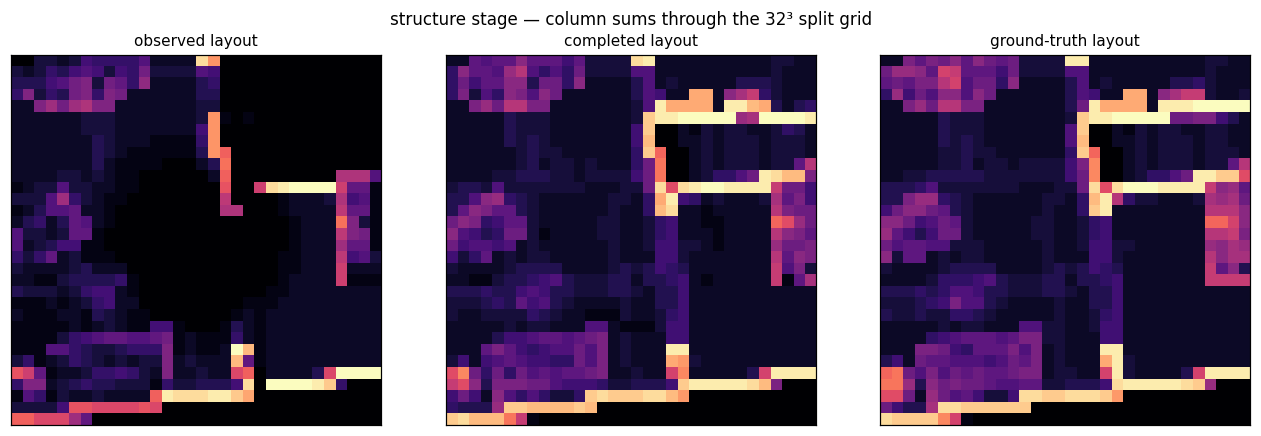

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, vol, t in zip(axes,
                      [split_known, split_out, split_gt],
                      ["observed layout", "completed layout", "ground-truth layout"]):
    ax.imshow((vol[0,0] > 0).float().sum(-1).cpu(), origin="lower", cmap="magma")
    ax.set_title(t, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("structure stage — column sums through the 32³ split grid", fontsize=11)
fig.tight_layout()

## 5. Complete the semantics

The completed layout becomes a depth-6 octree, and the semantic diffusion model fills
in class labels on its nodes. The known region is carried over as a per-node mask.

One subtlety worth knowing: the octree is rebuilt at `full_depth=3` rather than taken
straight from `split2octree_small` (which is dense at depth 4). The semantic model was
trained on the sparse version, and the dual-octree graph it consumes includes those
coarse nodes — feeding it the dense one is a graph it has never seen.

In [9]:
octree = split_big_to_octree(split_out, pipe.sem_full_depth)
doctree = build_doctree(octree)
node_mask = voxel_mask_to_node_mask(known, octree, doctree)

print(f"octree nodes per depth {octree.nnum.tolist()}")
print(f"latent rows {doctree.total_num:,}   conditioned {node_mask.mean():.1%}")

completed = pipe.inpaint_semantics(octree, partial, node_mask,
                                   steps=STEPS, resample=RESAMPLE)
print(f"completed scene: {int((completed>0).sum()):,} occupied voxels, "
      f"{len(completed.unique())} classes")

octree nodes per depth [1, 8, 64, 512, 2376, 11432, 47008]
latent rows 53,726   conditioned 26.8%
  loaded semantic_vae from <repo>/saved_model/vae_model_5.pt
  loaded semantic_diffusion from <repo>/saved_model/unet_sem_diffusion.pt


<env:octree-nb>/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


completed scene: 67,601 occupied voxels, 62 classes


## 6. Results

Left is the sensor input, middle is the completion, right is the ground truth the model
never saw.

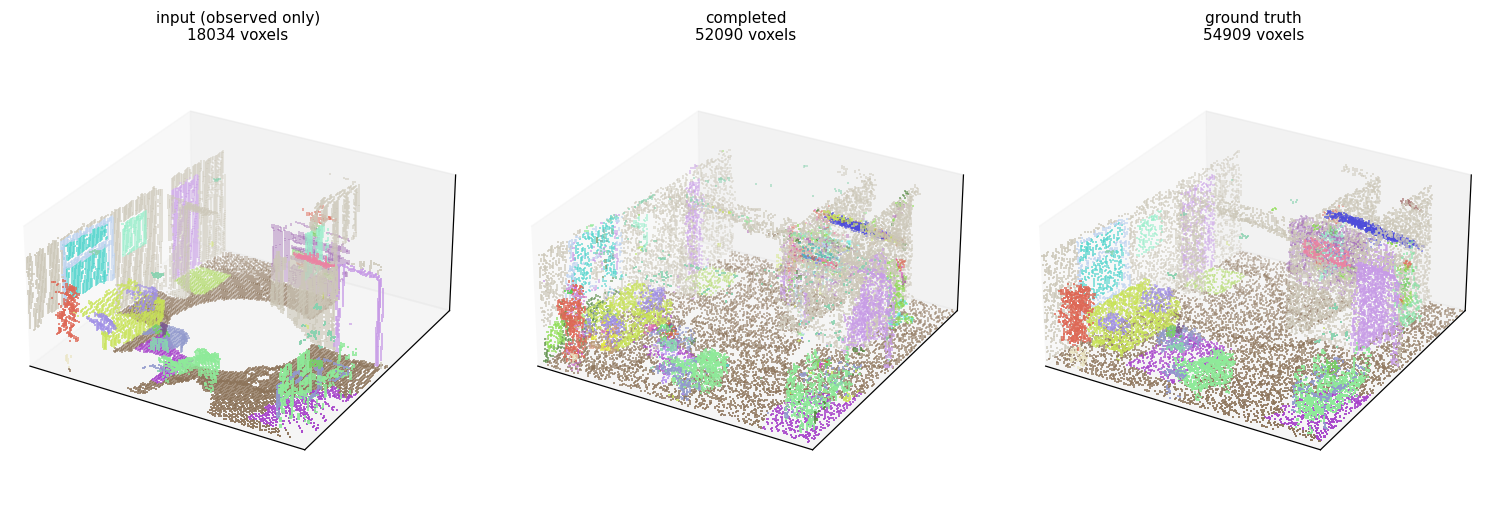

In [10]:
fig = compare_row([partial, completed, gt],
                  ["input (observed only)", "completed", "ground truth"],
                  figsize=(14, 4.6))

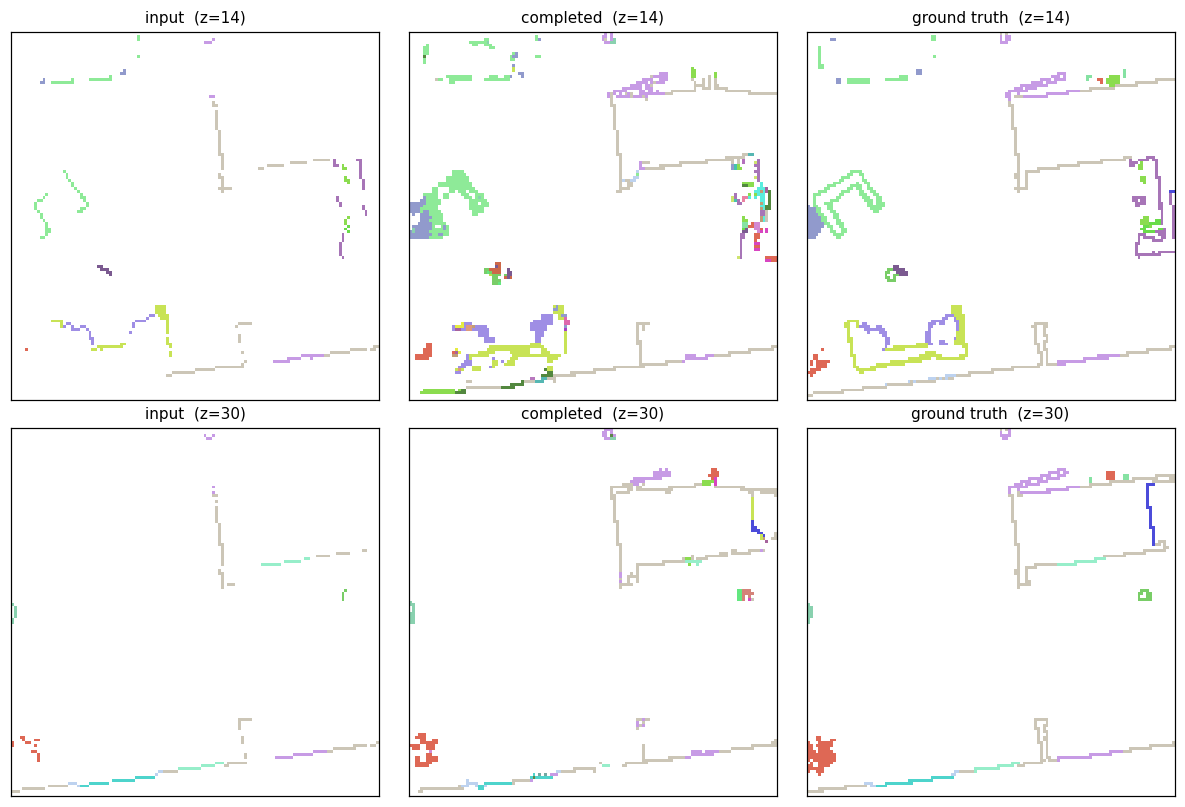

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(11, 7.4))
for row, z in zip(axes, [14, 30]):
    for ax, vol, t in zip(row, [partial, completed, gt], ["input", "completed", "ground truth"]):
        plot_slice(vol, z=z, ax=ax, title=f"{t}  (z={z})", colors=COLORS)
fig.tight_layout()

## 7. Metrics

The number that matters is **occluded** — accuracy on voxels the sensor could not see.
The observed number is a sanity check: it should sit near the semantic VAE's
reconstruction ceiling (~0.97), and if it is much lower then latents are leaking across
the mask boundary rather than the completion being wrong.

In [12]:
m = completion_metrics(completed, gt, known)
for k, v in m.items():
    print(f"{k:28s} {v:.4f}" if isinstance(v, float) else f"{k:28s} {v:,}")

observed_acc                 0.7915
observed_n                   24,907
occluded_acc                 0.4814
occluded_n                   45,831
occupancy_iou                0.5783
occluded_occupancy_iou       0.4656


In [13]:
# where do the errors fall? per-class accuracy on the occluded region
hidden = (gt > 0) & ~known
cls, counts = torch.unique(gt[hidden], return_counts=True)
order = counts.argsort(descending=True)[:8]

from octree_diff.viz.vis_indoor import label_name
print(f"{'class':>12} {'occluded voxels':>16} {'accuracy':>10}")
for i in order.tolist():
    c = int(cls[i]); sel = hidden & (gt == c)
    acc = (completed[sel] == c).float().mean().item()
    print(f"{label_name(c):>12} {int(counts[i]):>16,} {acc:>10.3f}")

       class  occluded voxels   accuracy
        wall            9,996      0.455
     ceiling            8,956      0.765
       floor            6,820      0.769
    class 38            3,684      0.426
    class 21            3,235      0.071
    class 24            2,652      0.368
    class 73            2,090      0.350
    class 74            1,911      0.334


## 8. Vary the viewpoint

Coverage varies a lot with where the sensor stands, so completion difficulty does too.
This sweeps a few heights on the same scene.

In [14]:
rows = []
for hf in [0.25, 0.40, 0.60]:
    vp = pick_viewpoint(occ, height_frac=hf)
    st = simulate_sensor(occ, vp, device=DEVICE)
    part, kn = observed_labels(gt, st)

    sp = pipe.inpaint_structure(labels_to_split_big(part, DEVICE),
                                voxel_mask_to_latent_mask(kn),
                                steps=STEPS, resample=RESAMPLE)
    oc = split_big_to_octree(sp, pipe.sem_full_depth)
    dt = build_doctree(oc)
    comp = pipe.inpaint_semantics(oc, part, voxel_mask_to_node_mask(kn, oc, dt),
                                  steps=STEPS, resample=RESAMPLE)
    mm = completion_metrics(comp, gt, kn)
    rows.append((vp, float(kn.float().mean()), mm))
    print(f"viewpoint {vp}  observed {kn.float().mean():5.1%}  "
          f"occluded acc {mm['occluded_acc']:.3f}  occluded IoU {mm['occluded_occupancy_iou']:.3f}")

viewpoint (63, 63, 16)  observed 45.8%  occluded acc 0.499  occluded IoU 0.476


viewpoint (63, 63, 25)  observed 49.5%  occluded acc 0.523  occluded IoU 0.500


viewpoint (63, 63, 38)  observed 46.5%  occluded acc 0.524  occluded IoU 0.500


## 9. How repeatable is a completion?

Sampling is stochastic, so the same partial scene gives a different completion each
time. Most draws land in a tight band, but roughly **one in twenty degrades badly** —
measured on this scene, layout IoU 0.54 where every other seed gives 0.94.

The useful part: a bad draw also disagrees with the region the sensor *did* observe
(agreement ~0.89 vs ~0.98), and that is measurable without any ground truth. That is
what `best_of` exploits — sample the layout a few times, keep the one that best matches
the input, and the failure mode disappears.

The cell below shows the raw spread with `best_of=1` so you can see it.

In [15]:
runs = []
for r in range(6):
    torch.manual_seed(100 + r)
    sp, ag = pipe.inpaint_structure(split_known, latent_mask, steps=STEPS,
                                    resample=RESAMPLE, best_of=1, return_score=True)
    a, bb = sp > 0, split_gt > 0
    iou = ((a & bb).sum() / (a | bb).sum()).item()
    runs.append((iou, ag))
    flag = "  <-- degraded" if iou < 0.8 else ""
    print(f"seed {100+r}:  layout IoU {iou:.3f}   observed-region agreement {ag:.3f}{flag}")

iou = np.array([r[0] for r in runs]); ag = np.array([r[1] for r in runs])
print()
print(f"layout IoU   mean {iou.mean():.3f}  range {iou.min():.3f}-{iou.max():.3f}")
print(f"agreement    good draws {ag[iou>0.8].mean():.3f}   degraded draws "
      f"{ag[iou<=0.8].mean() if (iou<=0.8).any() else float('nan'):.3f}")

seed 100:  layout IoU 0.939   observed-region agreement 0.979


seed 101:  layout IoU 0.938   observed-region agreement 0.979


seed 102:  layout IoU 0.939   observed-region agreement 0.979


seed 103:  layout IoU 0.538   observed-region agreement 0.890  <-- degraded


seed 104:  layout IoU 0.939   observed-region agreement 0.979


seed 105:  layout IoU 0.939   observed-region agreement 0.979

layout IoU   mean 0.872  range 0.538-0.939
agreement    good draws 0.979   degraded draws 0.890


The two are cleanly separable, so `best_of=3` (used above) is enough to avoid the bad
draws in practice at 3x the structure-stage cost. The structure stage is the cheap one,
so that is a good trade.

## Notes

- `--repaint-resample` is the main quality knob for completion; 1 is fastest, 4 is a
  reasonable default here. Everything above is also available from the command line:

  ```bash
  python -m inference_scripts.inference_indoor --mode inpaint \
      --input scene.pt --known-mask known.pt --repaint-resample 4 --out out/complete
  ```

- `python -m inference_scripts.verify_indoor` runs the same checks non-interactively,
  plus unconditional generation and +x outpainting.
- The sensor model is a simple range sensor: no noise, no depth quantisation, and it
  sees through nothing. A real depth camera would have a narrower field of view and
  return fewer surfaces, so treat these numbers as an optimistic bound.